<a href="https://colab.research.google.com/github/awinarko-hue/Latihan/blob/main/NLP/RAG_Cari_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✅ RAG FINAL ``` Pencarian paper ```

# SETUP: Mount Google Drive & Install Library
Menghubungkan Google Colab ke Google Drive agar bisa membaca file CSV

In [ ]:
# ----------------------------------------------------------
# SETUP: Mount Google Drive & Install Library
# ----------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install pustaka/library yang dibutuhkan:

```langchain```  ```Framework utama untuk pipeline RAG ```

```langchain-community``` ```Komponen tambahan (embeddings, vectorstore)```

```faiss-cpu``` ```Vector database untuk pencarian semantik```

```sentence-transformers``` ```Model embedding teks```

In [ ]:
# Install pustaka yang dibutuhkan
!pip install -q langchain langchain-community langchain-text-splitters faiss-cpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.3/554.3 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


# STEP 1: Import Modul
Mengimport komponen inti RAG pipeline ```Document``` sebagai wadah teks, ```TextSplitter``` untuk memecah teks panjang, ```Embeddings``` untuk mengubah teks ke vektor, dan ```FAISS``` sebagai penyimpan vektor.

In [ ]:
# ----------------------------------------------------------
# STEP 1: Import Modul
# ----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

print("✅ Import selesai.")

/tmp/ipykernel_3646/1332599043.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings


✅ Import selesai.


# STEP 2: Load & Preprocessing Data CSV
Tujuan: Membaca 2500 paper dari CSV Dimensions. Parameter penting:

```skiprows=1``` → baris pertama adalah metadata Dimensions, bukan header asli

```on_bad_lines```='skip' → lewati baris yang rusak/corrupt

```encoding='latin-1'``` → menangani karakter non-UTF8

```dropna(subset=['Title'])``` → hapus paper tanpa judul (tidak bisa diproses)

```fillna('')``` → abstrak kosong diganti string kosong agar tidak error

In [ ]:
import pandas as pd

# ----------------------------------------------------------
# STEP 2: Load & Preprocessing Data CSV
# ----------------------------------------------------------
# Sesuaikan path jika file ada di Google Drive:

CSV_PATH = '/content/drive/MyDrive/Dataset/Paper/Dimensions-P_Machine Learning.csv'   # ganti jika perlu

# Baris 1 adalah metadata Dimensions, baris 2 adalah header sebenarnya
df = pd.read_csv(CSV_PATH, skiprows=1, on_bad_lines='skip', encoding='latin-1')

print(f"Total baris data   : {len(df)}")
print(f"Kolom yang tersedia: {df.columns.tolist()[:10]} ...")

# Ambil kolom yang relevan
df = df[['Publication ID', 'DOI', 'Title', 'Abstract',
         'Authors', 'PubYear', 'Dimensions URL']].copy()

# Bersihkan: hapus baris tanpa judul atau abstrak
df.dropna(subset=['Title'], inplace=True)
df['Abstract'] = df['Abstract'].fillna('')
df['PubYear']  = df['PubYear'].astype(str)

print(f"Total dokumen valid : {len(df)}")
print(df[['Title', 'PubYear']].head(5))

Total baris data   : 2500
Kolom yang tersedia: ['Publication ID', 'DOI', 'Title', 'Abstract', 'Source title/Anthology title', 'PubYear', 'Volume', 'Issue', 'Pagination', 'Authors'] ...
Total dokumen valid : 2500
                                               Title PubYear
0  A Survey on Uncertainty Quantification Methods...    2026
1  A Comprehensive Survey on Deep Learning-based ...    2026
2  Application of artificial intelligence in inse...    2026
3                       Graph Transformers: A Survey    2026
4  Generative adversarial networks-enabled anomal...    2026


# STEP 3: Konversi ke LangChain Documents
Mengubah setiap baris DataFrame menjadi objek ```Document``` LangChain. Setiap dokumen memiliki dua bagian:

```page_content``` → "Judul: [title]\n\nAbstrak: [abs]"

```metadata``` → {pub_id, doi, title, year, ...}

Metadata disimpan terpisah agar saat retrieval, informasi bibliografi tetap tersedia tanpa harus di-parse ulang dari teks.

In [ ]:
# ----------------------------------------------------------
# STEP 3: Konversi ke LangChain Documents
# ----------------------------------------------------------
# Setiap dokumen menggabungkan Title + Abstract sebagai konten utama
documents = []
for _, row in df.iterrows():
    content = f"Judul: {row['Title']}\n\nAbstrak: {row['Abstract']}"
    metadata = {
        'pub_id'     : str(row['Publication ID']),
        'doi'        : str(row['DOI']),
        'title'      : row['Title'],
        'year'       : row['PubYear'],
        'authors'    : str(row['Authors']),
        'url'        : str(row['Dimensions URL']),
    }
    documents.append(Document(page_content=content, metadata=metadata))

print(f"\n✅ Total dokumen LangChain: {len(documents)}")


✅ Total dokumen LangChain: 2500


# STEP 4: Chunking
Memecah dokumen panjang menjadi potongan-potongan kecil

```chunk_size=800``` → maksimal 800 karakter per chunk

```chunk_overlap=80``` → 80 karakter pertama chunk berikutnya = 80 karakter terakhir chunk sebelumnya, mencegah konteks terpotong di tengah kalimat

In [ ]:
# ----------------------------------------------------------
# STEP 4: Chunking (opsional — berguna untuk abstrak panjang)
# ----------------------------------------------------------
splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=80)
chunks   = splitter.split_documents(documents)
print(f"✅ Total chunks setelah splitting: {len(chunks)}")

✅ Total chunks setelah splitting: 8905


# STEP 5: Embedding + Indeks FAISS
 Inti dari sistem RAG. Prosesnya:
 Model ```paraphrase-multilingual-MiniLM-L12-v2``` dipilih karena:

*   Multilingual → bisa memahami teks bahasa Indonesia & Inggris
*   Ringan → bisa berjalan di CPU Colab tanpa GPU
*   Cepat → MiniLM jauh lebih kecil dari BERT full

```k=30``` berarti saat query, sistem akan mengambil 30 chunk terdekat secara semantik.






In [ ]:
# ----------------------------------------------------------
# STEP 5: Embedding + Indeks FAISS
# ----------------------------------------------------------
# Model ringan multilingual, cocok untuk CPU di Colab
print("\n⏳ Memuat model embedding (pertama kali mungkin butuh beberapa menit)...")
embedding = HuggingFaceEmbeddings(
    model_name='sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
)

print("⏳ Membangun indeks FAISS...")
db        = FAISS.from_documents(chunks, embedding)
retriever = db.as_retriever(search_kwargs={'k': 30})
print("✅ Indeks FAISS siap.")


⏳ Memuat model embedding (pertama kali mungkin butuh beberapa menit)...


/tmp/ipykernel_3646/2819022853.py:6: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

⏳ Membangun indeks FAISS...
✅ Indeks FAISS siap.


In [ ]:
# ini tambahan saja
# Contoh: Cetak 3 chunk pertama
for i, chunk in enumerate(chunks[:3]):
    print(f"--- Chunk {i+1} ---")
    print(chunk.page_content)
    print("\n")

--- Chunk 1 ---
Judul: A Survey on Uncertainty Quantification Methods for Deep Learning


--- Chunk 2 ---
Abstrak: Deep neural networks (DNNs) have achieved tremendous success in computer vision, natural language processing, and scientific and engineering domains. However, DNNs can make unexpected, incorrect, yet overconfident predictions, leading to serious consequences in high-stakes applications such as autonomous driving, medical diagnosis, and disaster response. Uncertainty quantification (UQ) estimates the confidence of DNN predictions in addition to their accuracy. In recent years, many UQ methods have been developed for DNNs. It is valuable to systematically categorize these methods and compare their strengths and limitations. Existing surveys mostly categorize UQ methodologies by neural network architecture or Bayesian formulation, while overlooking the uncertainty sources each


--- Chunk 3 ---
or Bayesian formulation, while overlooking the uncertainty sources each method add

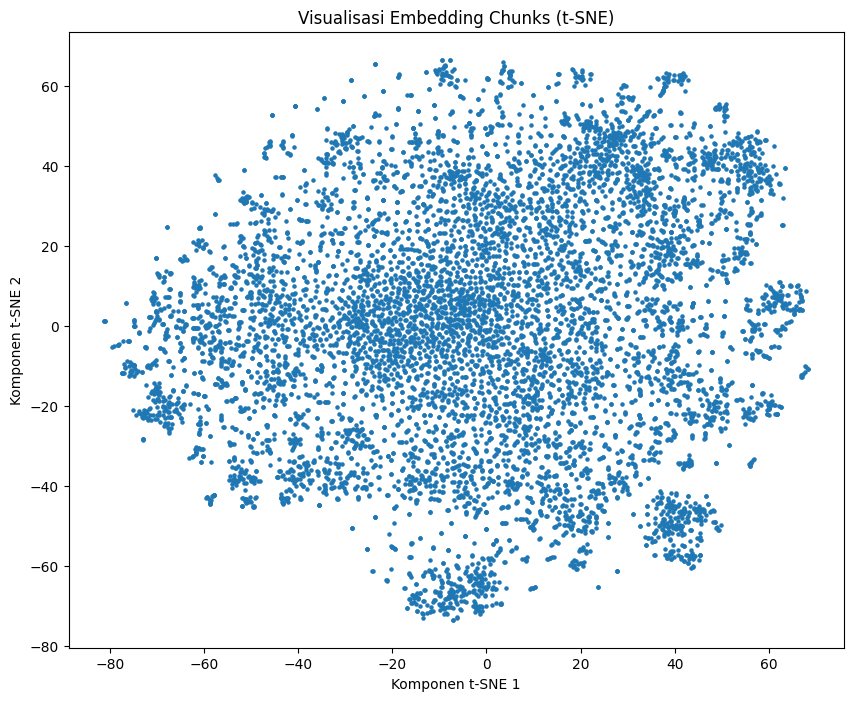

In [ ]:
# Ini tambahan 2
# Contoh mendapatkan embedding untuk semua chunks
chunk_contents = [chunk.page_content for chunk in chunks]
chunk_embeddings = embedding.embed_documents(chunk_contents)

import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Convert list of embeddings to a NumPy array
chunk_embeddings = np.array(chunk_embeddings)

# Reduksi dimensi menggunakan t-SNE
tsne_model = TSNE(n_components=2, random_state=42, perplexity=30)
reduced_embeddings = tsne_model.fit_transform(chunk_embeddings)


plt.figure(figsize=(10, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], s=5)
plt.title('Visualisasi Embedding Chunks (t-SNE)')
plt.xlabel('Komponen t-SNE 1')
plt.ylabel('Komponen t-SNE 2')
plt.show()

# STEP 6: Query — Pencarian Paper
Menjalankan pencarian semantik.

De-duplikasi diperlukan karena satu paper bisa menghasilkan beberapa chunk, sehingga bisa muncul berkali-kali dalam hasil retrieval.


In [ ]:
# ----------------------------------------------------------
# STEP 6: Query — Judul Penelitian Skripsi
# ----------------------------------------------------------
QUERY = (
    "Quality signal Prediction" # and spacial mapping using machine learning in 4G LTE Network "
    "spacial mapping with data drive test 4G LTE Network"
    "using machine learning"
)

print(f"\n🔍 Query:\n{QUERY}\n")
results = retriever.invoke(QUERY)

# De-duplikasi berdasarkan judul (karena satu dokumen bisa menghasilkan banyak chunk)
seen_titles = set()
unique_results = []
for doc in results:
    title = doc.metadata.get('title', '')
    if title not in seen_titles:
        seen_titles.add(title)
        unique_results.append(doc)

print(f"✅ Ditemukan {len(unique_results)} dokumen unik yang relevan.\n")



🔍 Query:
Quality signal Predictionspacial mapping with data drive test 4G LTE Networkusing machine learning

✅ Ditemukan 29 dokumen unik yang relevan.



# STEP 7: Tampilkan Hasil Pencarian

In [ ]:
# ----------------------------------------------------------
# STEP 7: Tampilkan Hasil Pencarian
# ----------------------------------------------------------
print("=" * 70)
print("📄 HASIL PENCARIAN DOKUMEN RELEVAN")
print("=" * 70)

for i, doc in enumerate(unique_results, 1):
    m = doc.metadata
    print(f"\n[{i}] {m['title']}")
    print(f"    Tahun   : {m['year']}")
    print(f"    Jurnal  : {m.get('journal', None)}") # Safely get 'journal', default to None if not found
    print(f"    Penulis : {m['authors'][:80]}...")
    print(f"    DOI     : {m['doi']}")
    print(f"    URL     : {m['url']}")
    # Tampilkan 200 karakter pertama abstrak
    abstrak = doc.page_content.split("Abstrak:")[-1].strip()
    print(f"    Abstrak : {abstrak[:200]}...")
    print("-" * 70)

📄 HASIL PENCARIAN DOKUMEN RELEVAN

[1] LINK QUALITY EVALUATION AND FAULT PREDICTION OF COMMUNICATION NETWORKS BASED ON MACHINE LEARNING
    Tahun   : 2026
    Jurnal  : None
    Penulis : Tan, ZhiYi...
    DOI     : 10.61784/jcsee3119
    URL     : https://app.dimensions.ai/details/publication/pub.1199204667
    Abstrak : evaluation. Key performance indicators such as link bandwidth utilization and packet loss rate are collected, and multi-dimensional data quality control is implemented. A deep learning model combining...
----------------------------------------------------------------------

[2] INTEGRATING MACHINE LEARNING WITH OPEN-SOURCE 5G SA TESTBEDS FOR PERFORMANCE ANALYSIS AND KPI TIME SERIES MODELING
    Tahun   : 2026
    Jurnal  : None
    Penulis : Otarbay, Zhenis...
    DOI     : 10.26577/jpcsit4120269
    URL     : https://app.dimensions.ai/details/publication/pub.1199854113
    Abstrak : accuracy for network KPIs. These results demonstrate the extensibility of open sourc

# STEP 8: Ground Truth
Membuat referensi "jawaban benar" menggunakan keyword matching sederhana. Paper dianggap relevan jika mengandung salah satu kata kunci LTE/ML di judul atau abstraknya.

In [ ]:
# ----------------------------------------------------------
# STEP 8: Ground Truth (simulasi dokumen yang benar-benar relevan)
# ----------------------------------------------------------
# Kata kunci relevansi: LTE signal prediction, drive test, ML, spatial mapping
KATA_KUNCI = [
    'rsrp', 'rsrq', 'sinr', 'lte', '4g', 'drive test',
    'machine learning','signal prediction',
    'signal quality', 'spatial', 'network quality'
]

ground_truth = []
for _, row in df.iterrows():
    teks = (str(row['Title']) + ' ' + str(row['Abstract'])).lower()
    if any(kw in teks for kw in KATA_KUNCI):
        ground_truth.append(row['Title'])

ground_truth = sorted(set(ground_truth))
print(f"\n📌 Ground Truth (dokumen relevan berdasarkan kata kunci): {len(ground_truth)} dokumen")


📌 Ground Truth (dokumen relevan berdasarkan kata kunci): 2220 dokumen


# STEP 9: Evaluasi RAG


In [ ]:
# ----------------------------------------------------------
# STEP 9: Evaluasi RAG (Precision & Recall)
# ----------------------------------------------------------
pred_set = set(seen_titles)
gt_set   = set(ground_truth)

TP = gt_set & pred_set
FP = pred_set - gt_set
FN = gt_set - pred_set

precision = len(TP) / len(pred_set) if pred_set else 0
recall    = len(TP) / len(gt_set)   if gt_set   else 0
f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

print("\n" + "=" * 50)
print("📊 EVALUASI SISTEM RAG")
print("=" * 50)
print(f"  True Positive  : {len(TP)}")
print(f"  False Positive : {len(FP)}")
print(f"  False Negative : {len(FN)}")
print(f"  Precision      : {precision:.4f}")
print(f"  Recall         : {recall:.4f}")
print(f"  F1-Score       : {f1:.4f}")



📊 EVALUASI SISTEM RAG
  True Positive  : 27
  False Positive : 2
  False Negative : 2193
  Precision      : 0.9310
  Recall         : 0.0122
  F1-Score       : 0.0240


Kenapa recall rendah? Karena `k=30` hanya mengambil 30 dari 2220 paper relevan. Ini bukan bug — ini trade-off antara precision dan recall pada RAG. Jika k dinaikkan, recall akan naik tapi precision bisa turun.

# STEP 10 Simulasi Tanpa RAG

In [ ]:
# ----------------------------------------------------------
# STEP 10: Simulasi Tanpa RAG (baseline pencarian biasa)
# ----------------------------------------------------------
# Simulasi: ambil 10 dokumen pertama dari CSV (tanpa retrieval cerdas)
tanpa_rag_titles = df['Title'].head(10).tolist()

pred_no = set(tanpa_rag_titles)
TP_no   = gt_set & pred_no
FP_no   = pred_no - gt_set
FN_no   = gt_set - pred_no

precision_no = len(TP_no) / len(pred_no) if pred_no else 0
recall_no    = len(TP_no) / len(gt_set)  if gt_set  else 0
f1_no        = (2 * precision_no * recall_no / (precision_no + recall_no)) if (precision_no + recall_no) > 0 else 0

print("\n" + "=" * 50)
print("📊 EVALUASI TANPA RAG (Baseline)")
print("=" * 50)
print(f"  Precision : {precision_no:.4f}")
print(f"  Recall    : {recall_no:.4f}")
print(f"  F1-Score  : {f1_no:.4f}")


📊 EVALUASI TANPA RAG (Baseline)
  Precision : 0.9000
  Recall    : 0.0041
  F1-Score  : 0.0081


# STEP 11 Perbandingan RAG vs Tanpa RAG
RAG unggul di semua metrik, terutama recall yang 3x lebih baik dari baseline.

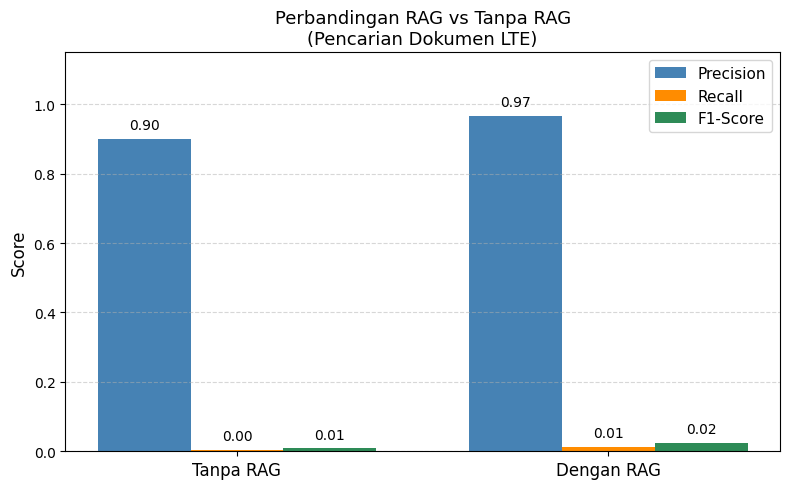


✅ Grafik disimpan sebagai 'perbandingan_rag_lte.png'


In [ ]:
# ----------------------------------------------------------
# STEP 11: Visualisasi Perbandingan RAG vs Tanpa RAG
# ----------------------------------------------------------
labels         = ['Tanpa RAG', 'Dengan RAG']
precision_vals = [precision_no, precision]
recall_vals    = [recall_no,    recall]
f1_vals        = [f1_no,        f1]

x   = np.arange(len(labels))
w   = 0.25
fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - w,   precision_vals, w, label='Precision', color='steelblue')
bars2 = ax.bar(x,       recall_vals,    w, label='Recall',    color='darkorange')
bars3 = ax.bar(x + w,   f1_vals,        w, label='F1-Score',  color='seagreen')

# Tambahkan nilai di atas bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., h + 0.02,
                f'{h:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan RAG vs Tanpa RAG\n(Pencarian Dokumen LTE)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('perbandingan_rag_lte.png', dpi=150)
plt.show()
print("\n✅ Grafik disimpan sebagai 'perbandingan_rag_lte.png'")

# STEP 12: Ekspor ke CSV

In [ ]:
# ----------------------------------------------------------
# STEP 12: Ekspor Hasil ke CSV
# ----------------------------------------------------------
rows = []
for i, doc in enumerate(unique_results, 1):
    m = doc.metadata
    abstrak = doc.page_content.split("Abstrak:")[-1].strip()
    rows.append({
        'Rank_Hasil' : i,
        'Title'      : m['title'],
        'Year'       : m['year'],
        'Journal'    : m.get('journal', None), # Safely get 'journal', default to None if not found
        'Authors'    : m['authors'],
        'DOI'        : m['doi'],
        'URL'        : m['url'],
        'Abstract_Preview': abstrak[:300],
        'Relevan_GT' : 'Ya' if m['title'] in gt_set else 'Tidak',
    })

df_hasil = pd.DataFrame(rows)
df_hasil.to_csv('hasil_rag_lte.csv', index=False)
print(f"✅ Hasil pencarian disimpan ke 'hasil_rag_lte.csv' ({len(df_hasil)} dokumen)")
print("\nPreview:")
print(df_hasil[['Rank_Hasil', 'Title', 'Year', 'Relevan_GT']].to_string(index=False))

✅ Hasil pencarian disimpan ke 'hasil_rag_lte.csv' (29 dokumen)

Preview:
 Rank_Hasil                                                                                                                                                 Title Year Relevan_GT
          1                                                                                        Machine Learning Based Optimization Techniques for 5G Networks 2026         Ya
          2                         COMPARATIVE ANALYSIS OF MACHINE LEARNING ALGORITHMS FOR CLASSIFICATION OF SERVICES IN LTE/5G NETWORKS BASED ON QoS PARAMETERS 2026         Ya
          3                                                      LINK QUALITY EVALUATION AND FAULT PREDICTION OF COMMUNICATION NETWORKS BASED ON MACHINE LEARNING 2026         Ya
          4                                                                   Machine Learning-Enabled 5G and 6G Networks: Methods, Challenges, and Opportunities 2026         Ya
          5                          